In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
!git config --global user.name "mafaiziyas"
!git config --global user.email "mohomed.20241805@iit.ac.lk"


USERNAME = "mafaiziyas"
TOKEN = token_deleted #to commit
REPO_NAME = "streamlit_cancer_predict_app"
EMAIL = "mohomed.20241805@iit.ac.lk"

#cloning repo to collab
repo_url = f"https://{TOKEN}@github.com/{USERNAME}/{REPO_NAME}.git"
!git clone {repo_url}

Cloning into 'streamlit_cancer_predict_app'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 16 (delta 0), reused 16 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 586.22 KiB | 5.80 MiB/s, done.


In [5]:
import os

%cd {REPO_NAME}

# Create professional folder
folders = ['data', 'notebooks', 'src', 'models', 'app', 'api']
for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"Created: {folder}/")

!pwd  #Verify

/content/streamlit_cancer_predict_app
Created: data/
Created: notebooks/
Created: src/
Created: models/
Created: app/
Created: api/
/content/streamlit_cancer_predict_app


In [6]:
import shutil

# Move the files from Colab's default upload area into project's data folder
try:
    shutil.move('/content/drive/MyDrive/streamlit_cancer_predict_app/data/wdbc.data', 'data/wdbc.data')
    shutil.move('/content/drive/MyDrive/streamlit_cancer_predict_app/data/wdbc.names', 'data/wdbc.names')
except FileNotFoundError as e:
    print(f"Error: File not found - {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Error: File not found - [Errno 2] No such file or directory: '/content/drive/MyDrive/streamlit_cancer_predict_app/data/wdbc.data'


In [7]:
#Commit1
!git add .

# Commit the structure change
!git commit -m "Initial professional repository scaffolding and data setup"

# Push back up to main branch
!git push origin main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date


In [8]:
#Read Meta data file

# Updated path for your next cell
with open(f"/content/{REPO_NAME}/data/wdbc.names", "r") as f:
    print(f.read())

1. Title: Wisconsin Diagnostic Breast Cancer (WDBC)

2. Source Information

a) Creators: 

	Dr. William H. Wolberg, General Surgery Dept., University of
	Wisconsin,  Clinical Sciences Center, Madison, WI 53792
	wolberg@eagle.surgery.wisc.edu

	W. Nick Street, Computer Sciences Dept., University of
	Wisconsin, 1210 West Dayton St., Madison, WI 53706
	street@cs.wisc.edu  608-262-6619

	Olvi L. Mangasarian, Computer Sciences Dept., University of
	Wisconsin, 1210 West Dayton St., Madison, WI 53706
	olvi@cs.wisc.edu 

b) Donor: Nick Street

c) Date: November 1995

3. Past Usage:

first usage:

	W.N. Street, W.H. Wolberg and O.L. Mangasarian 
	Nuclear feature extraction for breast tumor diagnosis.
	IS&T/SPIE 1993 International Symposium on Electronic Imaging: Science
	and Technology, volume 1905, pages 861-870, San Jose, CA, 1993.

OR literature:

	O.L. Mangasarian, W.N. Street and W.H. Wolberg. 
	Breast cancer diagnosis and prognosis via linear programming. 
	Operations Research, 43(4), pag

The dataset is derived from fine-needle aspirate (FNA) images and measures 10 key cellular characteristics, including size, shape, texture, surface smoothness, symmetry, and structural complexity. Each characteristic is represented by three statistical metrics-Mean, Standard Error (SE), and Worst (average of the three largest values)-resulting in a total of 30 predictive features used for breast cancer classification and analysis.
<br>
This application demonstrates the use of machine learning techniques for breast cancer prediction using the Breast Cancer Wisconsin (Diagnostic) dataset from the UCI Machine Learning Repository.
<br>
Source: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

In [9]:
import pandas as pd

df = pd.read_csv("/content/streamlit_cancer_predict_app/data/wdbc.data")
df.head() #df doesnt seem to have the header

,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


In [10]:
#list of cols based on meta data
col_names = [
    "ID",
    "Diagnosis",
    # - Mean Values -
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",
    # -Standard Error (SE) Values -
    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",
    # - Worst (Largest) Values -
    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"]


In [11]:
df = pd.read_csv("/content/streamlit_cancer_predict_app/data/wdbc.data", names = col_names, index_col = "ID")
df.head()
df.info()#no missing values found. Data types seem to be accurate.
df.shape #(569, 31): could be prune to overfitting

<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave_points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                 

(569, 31)

#Data Profiling & EDA

In [12]:
df.describe() #mean and std heavily varies amongst different features, scaling required

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [13]:
df.describe(include='object')
df["Diagnosis"].unique() #M- Malignant= Canceer, B- Benign= Normal

array(['M', 'B'], dtype=object)

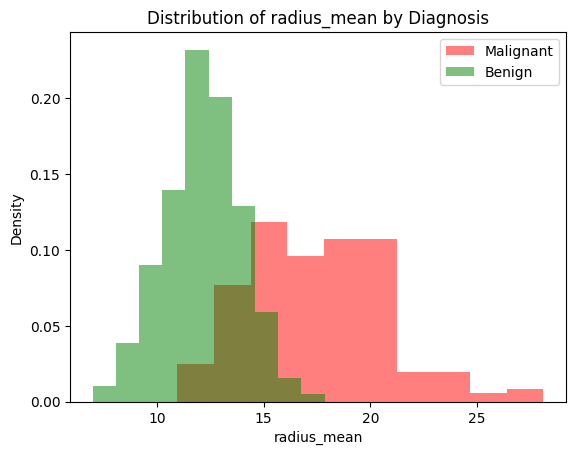

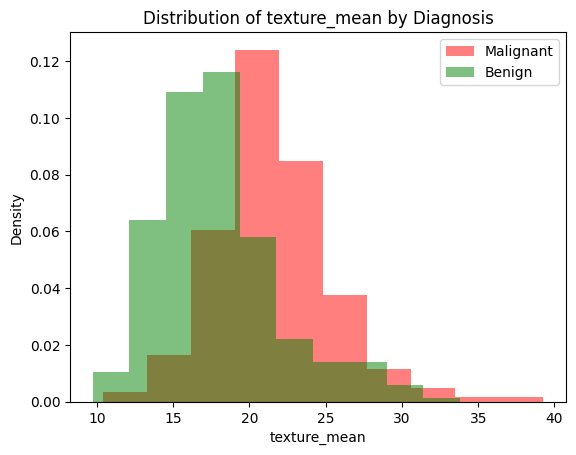

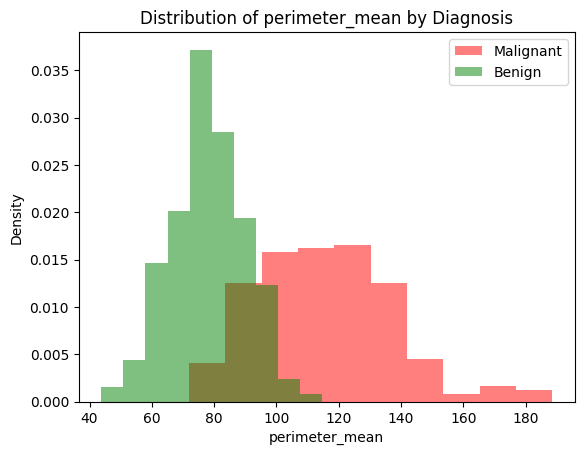

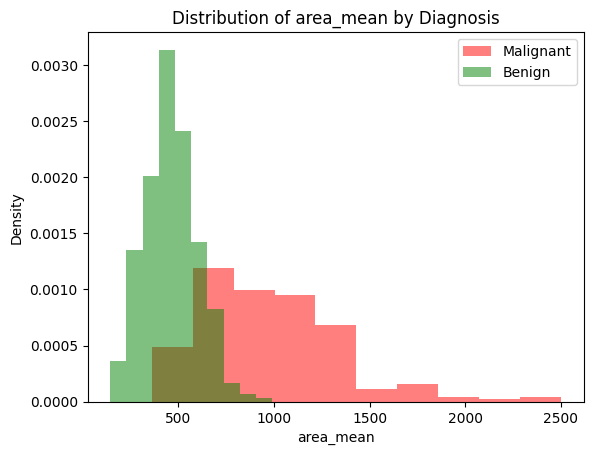

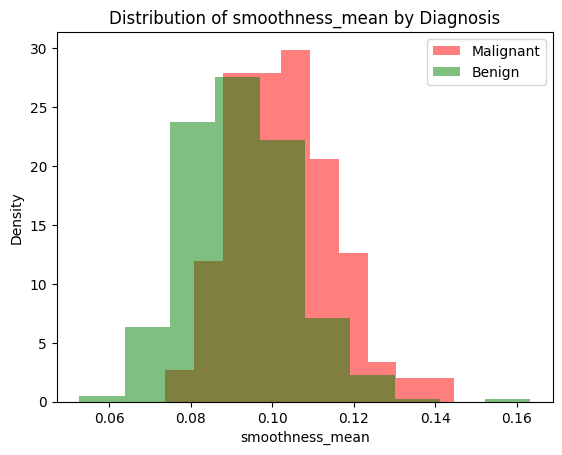

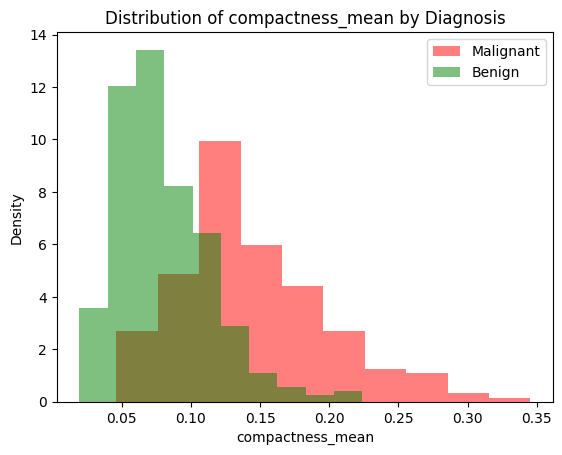

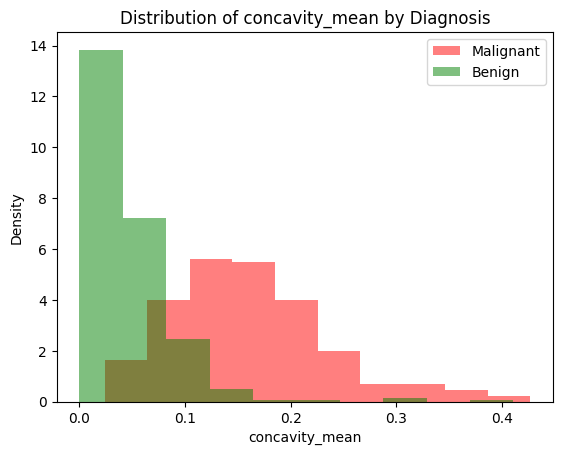

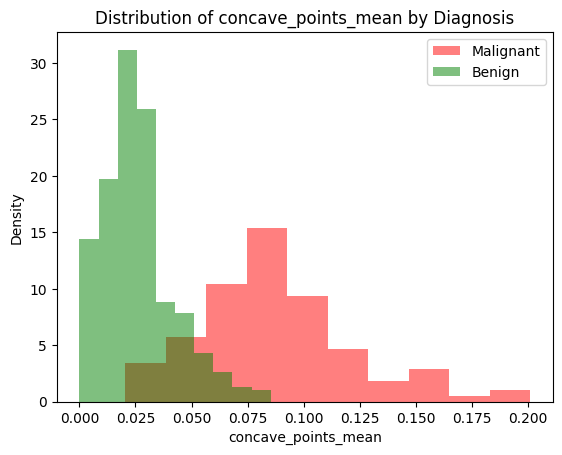

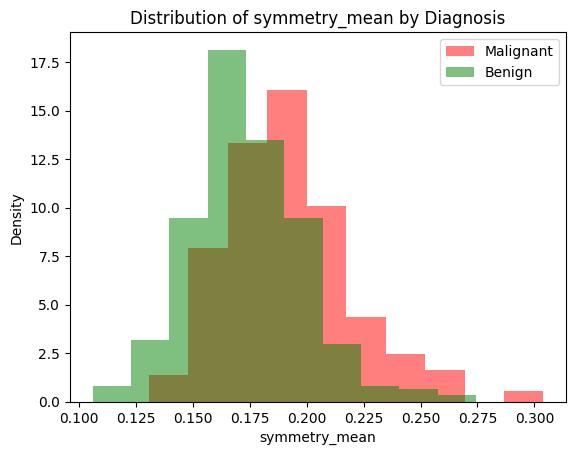

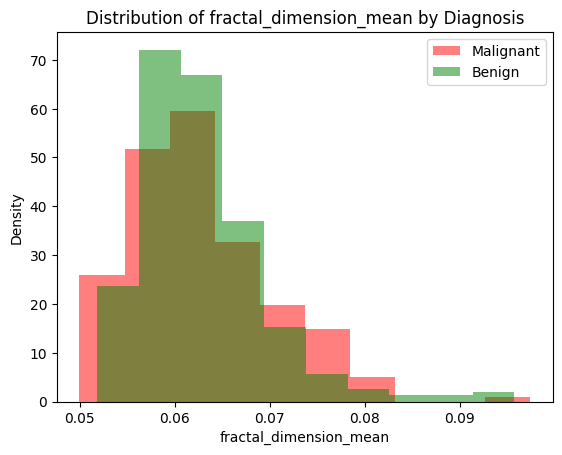

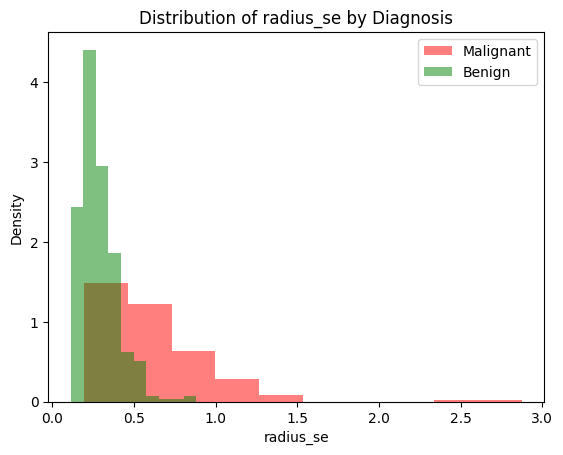

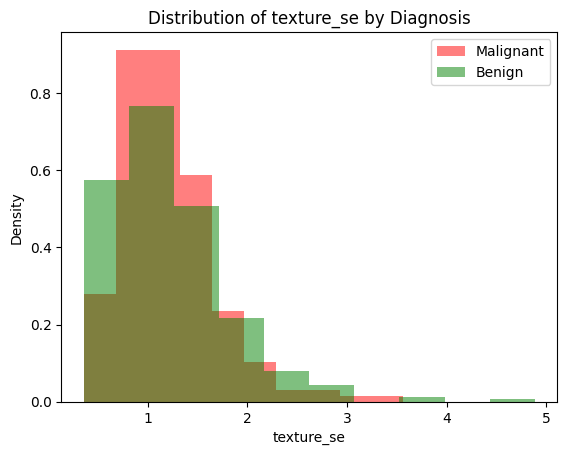

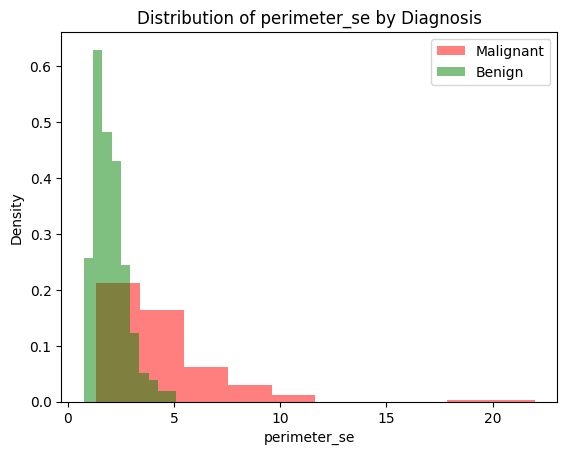

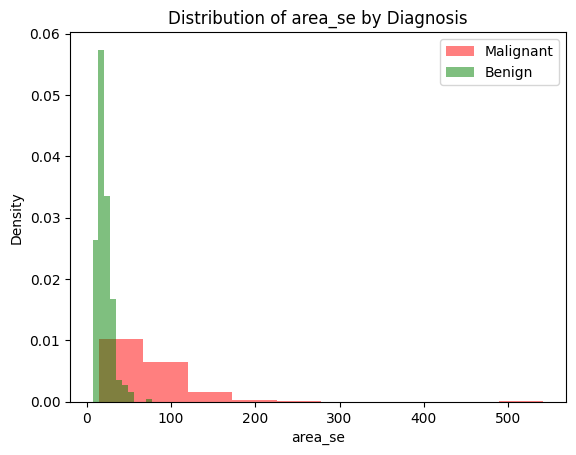

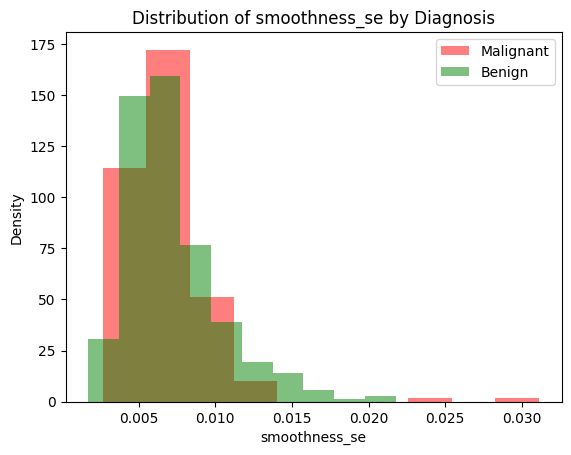

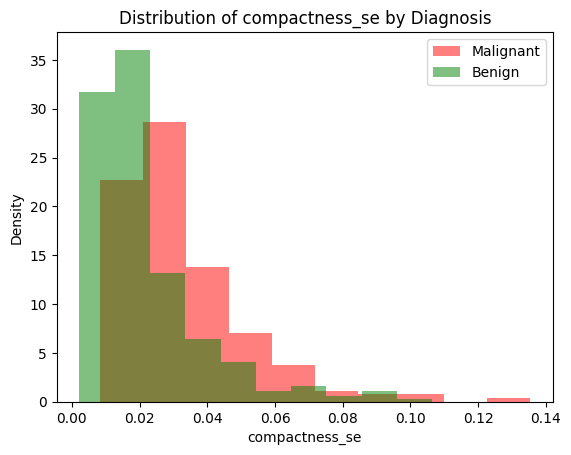

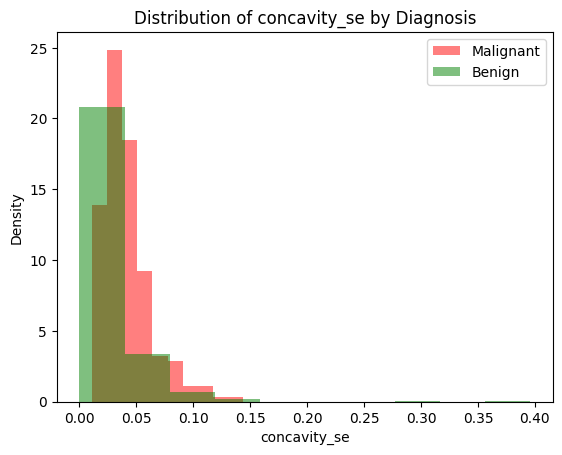

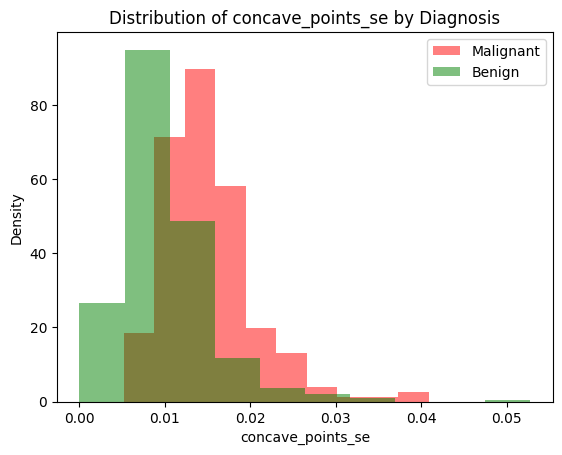

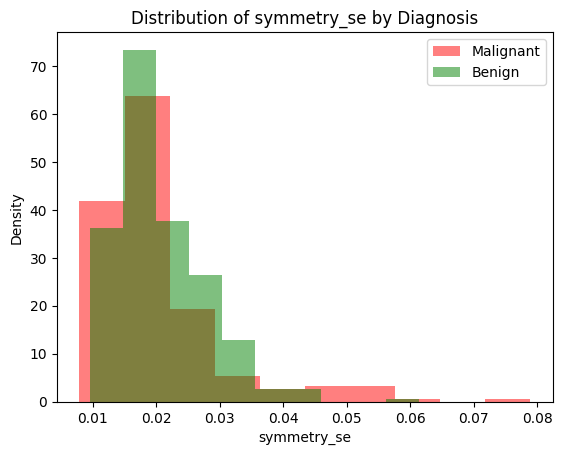

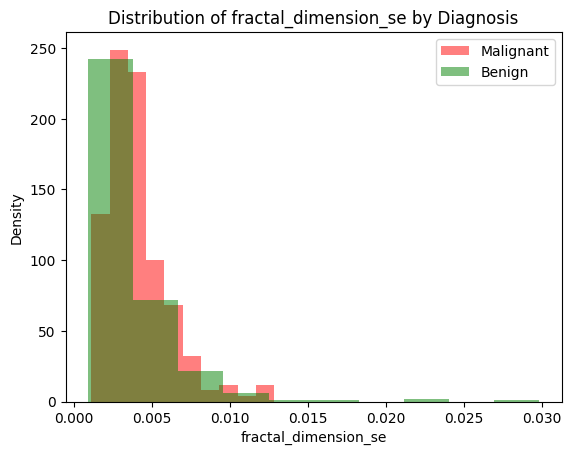

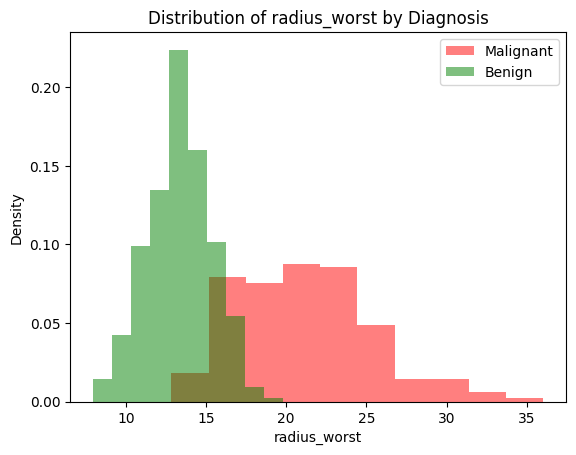

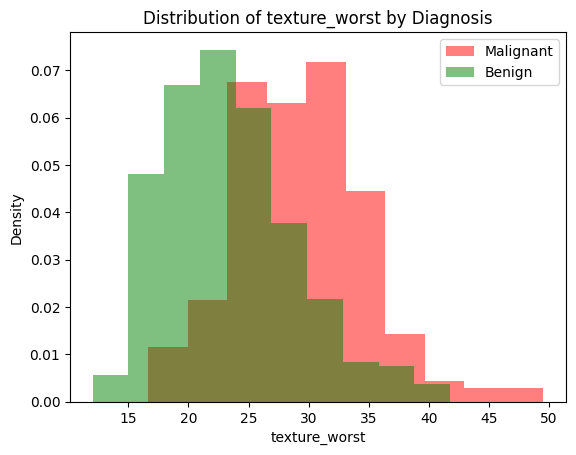

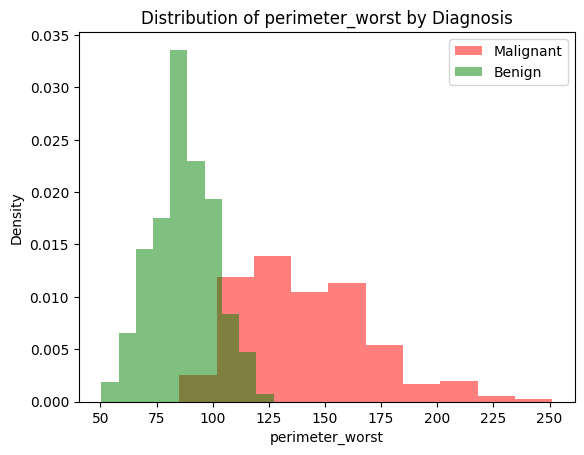

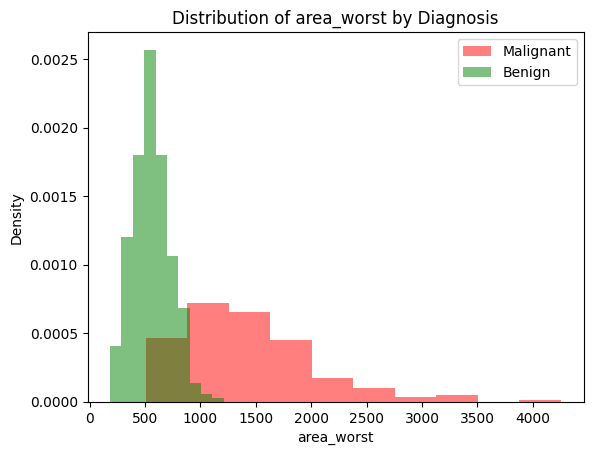

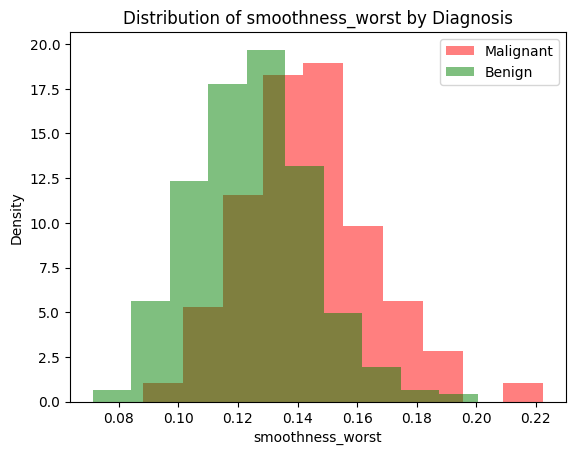

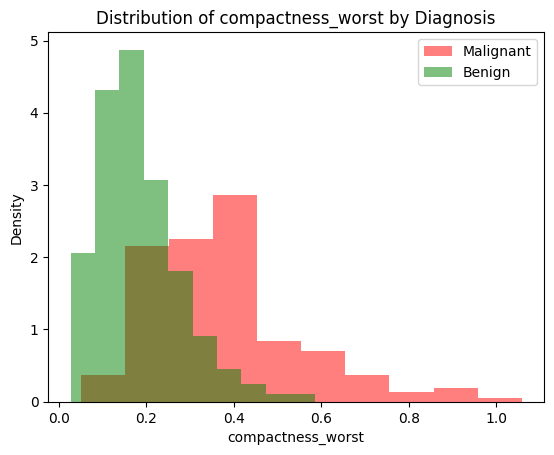

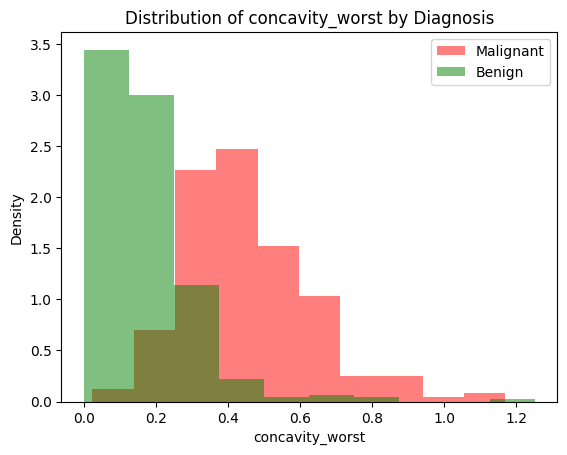

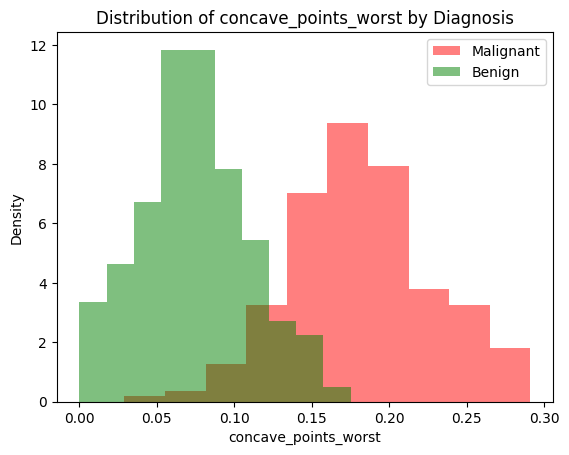

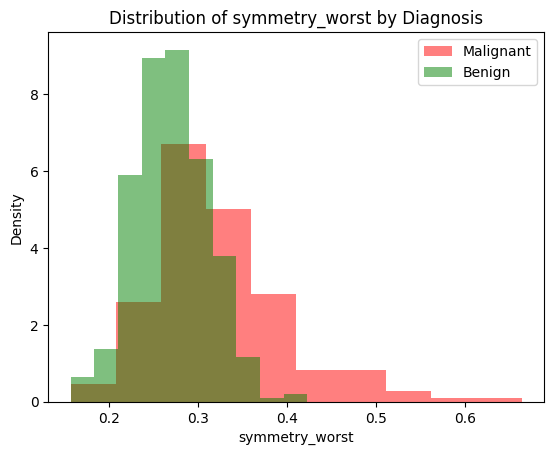

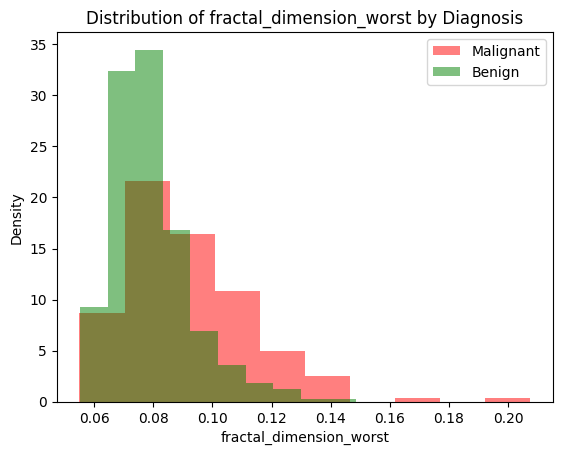

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

for col_name in col_names[2:]:
  plt.hist(df.loc[df["Diagnosis"]=="M", col_name], label="Malignant", alpha=0.5, density=True, color="red")
  plt.hist(df.loc[df["Diagnosis"]=="B", col_name], label="Benign", alpha=0.5, density=True, color="green")
  plt.legend()
  plt.title(f"Distribution of {col_name} by Diagnosis")
  plt.xlabel(col_name)
  plt.ylabel("Density")
  plt.show()

Features seem to have

#Prepping for model

In [15]:
print(df.loc[df["Diagnosis"]=="M"].shape)
df.loc[df["Diagnosis"]=="B"].shape #not much of a class imbalance observed

(212, 31)


(357, 31)

In [16]:
from sklearn.model_selection import train_test_split

# Encode target: Malignant = 1, Benign = 0
df['Diagnosis'] = df['Diagnosis'].replace({'M': 1, 'B': 0})

# Split X and target y
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

X_train, X_temp, y_train, y_temp = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y)
#10% Validation and 10% Testing
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50,  random_state=42, stratify=y_temp)

# Verify the final sizes
print(f"Original Dataset: {X.shape[0]} samples\n")
print(f"Training set (80%):   {X_train.shape[0]} samples")
print(f"Validation set (10%): {X_val.shape[0]} samples")
print(f"Testing set (10%):    {X_test.shape[0]} samples")

Original Dataset: 569 samples

Training set (80%):   455 samples
Validation set (10%): 57 samples
Testing set (10%):    57 samples


/tmp/ipykernel_1054/580811040.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Diagnosis'] = df['Diagnosis'].replace({'M': 1, 'B': 0})


#ML Modelling

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

#Initializing and fit the Scaler on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Scaling val and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

###Logistic Regression

In [18]:
#LogisticRegression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

#Generate predictions
y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

In [19]:
print('TRAINING SET PERFORMANCE')
print('Accuracy of train data: ', accuracy_score(y_train, y_train_pred))
# To check for overfitting
print("-------------------------------------------------")
#Evaluate the Testing Model performance
print('VALIDATING SET PERFORMANCE')
print('Accuracy of our val data:  ', accuracy_score(y_val, y_val_pred))
print("-------------------------------------------------")
#Evaluate the Testing Model performance
print('TESTING SET PERFORMANCE')
print('Accuracy of our test model:  ', accuracy_score(y_test, y_test_pred))
print("\nClassification report: \n", classification_report(y_test, y_test_pred))

TRAINING SET PERFORMANCE
Accuracy of train data:  0.9868131868131869
-------------------------------------------------
VALIDATING SET PERFORMANCE
Accuracy of our val data:   0.9473684210526315
-------------------------------------------------
TESTING SET PERFORMANCE
Accuracy of our test model:   0.9824561403508771

Classification report: 
               precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.95      1.00      0.98        21

    accuracy                           0.98        57
   macro avg       0.98      0.99      0.98        57
weighted avg       0.98      0.98      0.98        57



Logistic Regression demonstrates an exceptional performance with ***98.6% training accuracy***, 94.7% validation accuracy, and a final 98.2% test accuracy. The close alignment between these metrics proves the model is ***highly generalized and not overfit***. A *test F1-score of 0.98* ensures robust, balanced classifications for medical diagnoses.

###SVM

In [20]:
#SVM
from sklearn.svm import SVC
svm_model = SVC(kernel='linear', C=10.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)

#Generate predictions
y_train_pred_svm = svm_model.predict(X_train_scaled)
y_val_pred_svm = svm_model.predict(X_val_scaled)
y_test_pred_svm = svm_model.predict(X_test_scaled)

In [21]:
print('TRAINING SET PERFORMANCE')
print('Accuracy of train data: ', accuracy_score(y_train, y_train_pred_svm))
# To check for overfitting
print("-------------------------------------------------")
#Evaluate the Testing Model performance
print('VALIDATING SET PERFORMANCE')
print('Accuracy of our val data:  ', accuracy_score(y_val, y_val_pred_svm))
print("-------------------------------------------------")
#Evaluate the Testing Model performance
print('TESTING SET PERFORMANCE')
print('Accuracy of our test model:  ', accuracy_score(y_test, y_test_pred_svm))
print("\nClassification report: \n", classification_report(y_test, y_test_pred_svm))

TRAINING SET PERFORMANCE
Accuracy of train data:  0.9956043956043956
-------------------------------------------------
VALIDATING SET PERFORMANCE
Accuracy of our val data:   0.9649122807017544
-------------------------------------------------
TESTING SET PERFORMANCE
Accuracy of our test model:   0.9824561403508771

Classification report: 
               precision    recall  f1-score   support

           0       0.97      1.00      0.99        36
           1       1.00      0.95      0.98        21

    accuracy                           0.98        57
   macro avg       0.99      0.98      0.98        57
weighted avg       0.98      0.98      0.98        57



The Support Vector Machine demonstrates phenomenal performance, achieving ***99.6% training accuracy***, 96.5% validation accuracy, and a final 98.2% test accuracy. This incredibly tight alignment confirms ***excellent generalization without overfitting***. A **perfect 1.00 recall for class 0 and high F1-score make it exceptionally reliable** for clinical breast cancer diagnostics.

In Medicine: Recall is usually prioritized above everything else. A False Negative can mean a patient goes untreated, which is life-threatening. Therefore, **Logistic Regression wins heavily** on safety here.

#Pickling

In [22]:
import pickle

#Winning model LogisticRegression is packed
model_artifacts = {
    "scaler": scaler,
    "model": model,
    "feature_names": list(X.columns)} #preserving feature order to fascillitate API building

# Save
with open("models/scaler_and_model.pkl", "wb") as f:
    pickle.dump(model_artifacts, f)



In [29]:
import shutil
import os

# 1. Define the folder path on your drive
colab_drive_folder = "/content/drive/MyDrive/Colab Notebooks/"
notebook_name = "main.ipynb"  # Make sure this matches your tab name exactly!

# Ensure your git notebooks folder exists
os.makedirs("notebooks", exist_ok=True)

# 2. Combine them cleanly using os.path.join to prevent string gluing errors
source_file = os.path.join(colab_drive_folder, notebook_name)
destination_file = "notebooks/01_eda_and_modeling.ipynb"

# 3. Duplicate the file into your repository layout
shutil.copy(source_file, destination_file)



'notebooks/01_eda_and_modeling.ipynb'

In [30]:
# Undo the last commit but keep your file changes safe
!git reset --soft HEAD~1

# Re-add the newly updated clean notebook and pickle file
!git add models/scaler_and_model.pkl notebooks/01_eda_and_modeling.ipynb

# Commit it fresh without any secrets inside the code history
!git commit -m "feat: complete modeling phase and export clean artifacts"

[main 70d37c1] feat: complete modeling phase and export clean artifacts
 2 files changed, 1 insertion(+)
 create mode 100644 models/scaler_and_model.pkl
 create mode 100644 notebooks/01_eda_and_modeling.ipynb


In [31]:
!git push origin main

Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (6/6), 548.07 KiB | 6.60 MiB/s, done.
Total 6 (delta 0), reused 0 (delta 0), pack-reused 0
remote: error: GH013: Repository rule violations found for refs/heads/main.
remote: 
remote: - GITHUB PUSH PROTECTION
remote:   —————————————————————————————————————————
remote:     Resolve the following violations before pushing again
remote: 
remote:     - Push cannot contain secrets
remote: 
remote:     
remote:      (?) Learn how to resolve a blocked push
remote:      https://docs.github.com/code-security/secret-scanning/working-with-secret-scanning-and-push-protection/working-with-push-protection-from-the-command-line#resolving-a-blocked-push
remote:     
remote:     
remote:       —— GitHub Personal Access Token ——————————————————————
remote:        locations:
remote:          - commit: 70d37c15b8ec6ba08a28ff536f11e7d2f40bda90